# Native RAS Mapper Terrain Export

Export a registered HEC-RAS terrain to one bounded, validated GeoTIFF with `RasTerrain.export_rasmapper_terrain()`. This example uses the portable **Muncie** project and its two-source `TerrainWithChannel` layer to demonstrate exact terrain selection, a source-aligned 2x grid, native stitch handling, the modification-rasterization option, structured results, and the machine-readable receipt.

The export is deliberately small and opt-in. It does not run a hydraulic simulation, modify the source terrain, or register the derivative back into the project.

## What the native wrapper preserves

The API loads the selected `TerrainLayer` from the project's `.rasmap`, then delegates consolidation and optional vector-modification rasterization to RAS Mapper. This retains registered source priority, stitches, masks, and modification behavior rather than rebuilding those rules in Python. The supervised helper writes a unique partial TIFF, validates it semantically, promotes it only on success, and writes a JSON receipt.

`RasTerrainMod` remains useful for terrain profiles, volume curves, and small analytical samples. It is not a fallback for this production raster-export path.

## Release and platform contract

The API checks an initialized `RasPrj` and its identifiable executable release before it creates output folders or starts native work.

| HEC-RAS release | Terrain-export status |
| --- | --- |
| 6.3 / 6.3.1 | Unsupported: the required bounded native contract is absent. |
| 6.4.0 | Unsupported because of the documented terrain-elevation defect. |
| 6.4.1, 6.5, 6.6 | Qualified on native Windows and under task-local Wine. |
| 6.7 beta builds | Unsupported; no final release was available to qualify. |
| 7.0.0 | Unsupported because of the documented terrain-modification export defect. |
| 7.0.1 | Qualified on native Windows and under task-local Wine. |
| 7.1 | Forward-open, not pre-qualified: an exact 7.1 installation may proceed, but the helper still verifies the managed method contract at runtime. |

This notebook defaults to 6.6 because it is the cross-platform-qualified release. On Windows the helper uses the matching local installation. On Linux it uses the Wine configuration established through `RasProcess.configure_wine()` and task-local process state; it supervises only the process tree it owns.

## Setup and parameters

Keep `RUN_NATIVE_EXPORT = False` for routine documentation and source QA. To reproduce the committed evidence on a machine with a qualified HEC-RAS 6.6 installation (or configured task-local Wine runtime), set `RAS_COMMANDER_RUN_NATIVE_TERRAIN_EXPORT=1` in the notebook kernel environment after reviewing the bounded parameters. Generated projects, rasters, receipts, and figures stay under the ignored `working/` tree.

In [1]:
# =============================================================================
# DEVELOPMENT MODE TOGGLE
# =============================================================================
# True uses this checkout; False uses an installed ras-commander package.

USE_LOCAL_SOURCE = True

import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if REPO_ROOT.name.lower() == "examples":
    REPO_ROOT = REPO_ROOT.parent

if USE_LOCAL_SOURCE:
    local_path = str(REPO_ROOT)
    if local_path not in sys.path:
        sys.path.insert(0, local_path)
    print("LOCAL SOURCE MODE: Loading from this checkout's ras_commander package")
else:
    print("PIP PACKAGE MODE: Loading installed ras-commander")

LOCAL SOURCE MODE: Loading from this checkout's ras_commander package


In [2]:
from __future__ import annotations

import json
import os
from pathlib import Path

import pandas as pd
from IPython.display import display

from ras_commander import (
    RasExamples,
    RasMap,
    RasTerrain,
    TerrainExportResult,
    init_ras_project,
)

RUN_NATIVE_EXPORT = False
if os.environ.get("RAS_COMMANDER_RUN_NATIVE_TERRAIN_EXPORT", "0") == "1":
    RUN_NATIVE_EXPORT = True
OVERWRITE_EXISTING = False
PROJECT_SUFFIX = "native_terrain_export_931"
RAS_VERSION = "6.6"
TERRAIN_NAME = "TerrainWithChannel"
DOWNSAMPLE_FACTOR = 2
RASTERIZE_MODIFICATIONS = True
TIMEOUT_SECONDS = 180.0
EXPORT_EXTENT = (
    404147.258781418,
    1801881.85296284,
    404307.258781418,
    1802111.85296284,
)

RUN_ROOT = Path(
    os.environ.get(
        "RAS_COMMANDER_EXAMPLE_RUN_ROOT",
        REPO_ROOT / "working" / "example_931_native_terrain_export",
    )
)
RUN_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_TIF = RUN_ROOT / "exports" / "muncie_terrain_with_channel_2x.tif"
REVIEW_FIGURE = RUN_ROOT / "review" / "muncie_terrain_export_evidence.png"

def run_path(path):
    """Return a portable label for an artifact under this run root."""
    return str(Path("run") / Path(path).resolve().relative_to(RUN_ROOT.resolve()))

print("Run root: run")
print(f"Native export enabled: {RUN_NATIVE_EXPORT}")
print(f"Overwrite enabled: {OVERWRITE_EXISTING}")
print(f"HEC-RAS release: {RAS_VERSION}")

Run root: run
Native export enabled: True
Overwrite enabled: False
HEC-RAS release: 6.6


## Extract and initialize the real project

`RasExamples` makes a writable project copy. Passing the resulting `RasPrj` into every project-aware API keeps version and multi-project state explicit.

In [3]:
project_path = RasExamples.extract_project(
    "Muncie",
    output_path=RUN_ROOT,
    suffix=PROJECT_SUFFIX,
)
ras = init_ras_project(
    project_path,
    ras_version=RAS_VERSION,
    load_results_summary=False,
)

print(f"Project: {ras.project_name}")
print(f"Project folder: {run_path(ras.project_folder)}")
print(f"Resolved HEC-RAS version: {ras.ras_version}")

2026-08-29 20:52:58 - ras_commander.RasExamples - INFO - Successfully extracted project 'Muncie' to Muncie_native_terrain_export_931
2026-08-29 20:52:58 - ras_commander.RasPrj - INFO - ras-commander v0.99.1 | An open-source project of CLB Engineering Corporation (https://clbengineering.com/) | Docs: https://rascommander.info | GitHub: https://github.com/gpt-cmdr/ras-commander
2026-08-29 20:52:58 - ras_commander.RasPrj - INFO - Project initialized: Muncie
2026-08-29 20:52:58 - ras_commander.RasPrj - INFO - Using HEC-RAS version 6.6
2026-08-29 20:52:58 - ras_commander.RasPrj - INFO - 
═══════════════════════════════════════════════════════════════════════
ras-commander | HEC-RAS Automation Library
Docs: https://rascommander.info/ras/
Repo: https://github.com/gpt-cmdr/ras-commander
LLM agents: https://rascommander.info/ras/llms.txt
═══════════════════════════════════════════════════════════════════════

SUPPORT OPEN-SOURCE DEVELOPMENT:
  Using RAS Commander? Please consider citing the lib

Project: Muncie
Project folder: run\Muncie_native_terrain_export_931
Resolved HEC-RAS version: 6.6


## Inventory first, then select exactly

`RasMap.list_terrain_layers()` is the DataFrame source of truth for registered terrain selection. The export API accepts an omitted name only when exactly one terrain is registered; this example deliberately requires one exact, case-sensitive match.

In [4]:
terrain_layers = RasMap.list_terrain_layers(
    project_path,
    ras_object=ras,
)
terrain_layers_review = terrain_layers.copy()
for path_column in ("filename", "resolved_path", "rasmap_path"):
    if path_column in terrain_layers_review.columns:
        terrain_layers_review[path_column] = terrain_layers_review[path_column].map(
            lambda value: Path(value).name if pd.notna(value) else value
        )
display(terrain_layers_review)

selected_rows = terrain_layers.loc[terrain_layers["name"] == TERRAIN_NAME]
if len(selected_rows.index) != 1:
    available = terrain_layers["name"].astype(str).tolist()
    raise ValueError(
        f"Expected one exact terrain named {TERRAIN_NAME!r}; found "
        f"{len(selected_rows.index)}. Available terrains: {available}"
    )

selected_terrain = selected_rows.iloc[0]
registered_before = terrain_layers[["name", "resolved_path"]].copy()
print(f"Selected terrain: {selected_terrain['name']}")
print(f"Registered terrain HDF: {Path(selected_terrain['resolved_path']).name}")

,name,filename,resolved_path,checked,type,resample_method,surface_on
0,Terrain,Terrain.hdf,Terrain.hdf,True,TerrainLayer,near,True
1,TerrainWithChannel,TerrainWithChannel.hdf,TerrainWithChannel.hdf,True,TerrainLayer,near,True


Selected terrain: TerrainWithChannel
Registered terrain HDF: TerrainWithChannel.hdf


## Exact source-derived resolution and grid alignment

`downsample_factor` accepts only **1, 2, 4, or 8**. Factor 1 consolidates at native resolution; factors 2, 4, and 8 multiply the authoritative source cell size exactly. The API does not round a US-survey-foot source to a nominal metre resolution. It snaps the requested extent outward to the authoritative source-grid origin and always uses nearest-neighbor for this path.

| Factor | Meaning | Exact output cell |
| ---: | --- | --- |
| 1 | Native consolidation | `native_cell_size` |
| 2 | Notebook execution example | `native_cell_size * 2` |
| 4 | Coarser derivative | `native_cell_size * 4` |
| 8 | Coarsest supported derivative | `native_cell_size * 8` |

For multi-source terrain, the result inventories every source and identifies the authoritative grid. Source resolutions may differ and need not have integer ratios: RAS Mapper consolidates them onto the explicit source-derived output grid. Preflight rejects only missing, non-finite, or non-positive level-zero source grids.

## Run the bounded native export

`rasterize_modifications=True` is passed to RAS Mapper's native `resampleVecMods` behavior. Muncie is used here to provide a portable two-source stitch example; use the terrain-modification notebook for an affected-versus-control-cell comparison across a known vector modification.

`overwrite=False` is the safe default. If either the requested TIFF or receipt already exists, the API raises rather than replacing it. Choose a new destination for a repeat run, or opt into replacement deliberately.

In [5]:
result = None

if RUN_NATIVE_EXPORT:
    result = RasTerrain.export_rasmapper_terrain(
        ras_project_path=project_path,
        output_tif=OUTPUT_TIF,
        terrain_name=TERRAIN_NAME,
        extent=EXPORT_EXTENT,
        downsample_factor=DOWNSAMPLE_FACTOR,
        rasterize_modifications=RASTERIZE_MODIFICATIONS,
        overwrite=OVERWRITE_EXISTING,
        timeout_seconds=TIMEOUT_SECONDS,
        ras_object=ras,
    )
    if not result:
        raise RuntimeError(
            f"Native terrain export failed: {result.error}; "
            f"receipt: {run_path(result.receipt_path)}"
        )
    assert isinstance(result, TerrainExportResult)
    print(result)
else:
    print("Native export skipped. Set RUN_NATIVE_EXPORT = True after reviewing the parameters.")
    print(f"Planned output: {run_path(OUTPUT_TIF)}")
    print(f"Requested bounded extent: {EXPORT_EXTENT}")

TerrainExportResult(SUCCESS, terrain='TerrainWithChannel', factor=2x, time=1.4s)


## Inspect the typed result and semantic validation

A successful `TerrainExportResult` is truthy only after both the GeoTIFF and receipt are promoted. The source inventory records priority, raster dimensions and extent, intersection with this window, and the authoritative-grid source. The validation dictionary records the actual grid, band semantics, value range, CRS presence, checksum, and absence of unexpected sidecars.

In [6]:
if result is not None:
    result_summary = pd.DataFrame(
        [
            {
                "result_type": type(result).__name__,
                "success": bool(result),
                "terrain_name": result.terrain_name,
                "native_cell_size": result.native_cell_size,
                "downsample_factor": result.downsample_factor,
                "output_cell_size": result.output_cell_size,
                "requested_extent": result.requested_extent,
                "snapped_extent": result.snapped_extent,
                "rasterize_modifications": result.rasterize_modifications,
                "elapsed_seconds": result.elapsed_seconds,
                "output_path": run_path(result.output_path),
            }
        ]
    )
    validation_summary = pd.Series(result.validation, name="validated_value").to_frame()

    source_inventory_review = result.source_inventory.copy()
    source_inventory_review["filename"] = source_inventory_review["filename"].map(
        lambda value: Path(value).name
    )

    display(result_summary)
    display(source_inventory_review)
    display(validation_summary)

    assert result.validation["driver"] == "GTiff"
    assert result.validation["band_count"] == 1
    assert result.validation["data_type"] == "Float32"
    assert result.validation["crs_present"] is True
    assert result.validation["sidecars"] == []
    assert result.source_inventory["intersects_output"].all()
    assert int(result.source_inventory["authoritative_grid"].sum()) == 1
else:
    print("Run the native export cell to populate result, source, and validation evidence.")

,result_type,success,terrain_name,native_cell_size,downsample_factor,output_cell_size,requested_extent,snapped_extent,rasterize_modifications,elapsed_seconds,output_path
0,TerrainExportResult,True,TerrainWithChannel,5.0,2,10.0,"(404147.258781418, 1801881.85296284, 404307.25...","(404147.258781418, 1801881.85296284, 404307.25...",True,1.424569,run\exports\muncie_terrain_with_channel_2x.tif


,index,filename,priority,columns,rows,extent,cell_sizes,levels,intersects_output,authoritative_grid
0,0,TerrainWithChannel.ChannelOnly.tif,0,1891,1155,"{'min_x': 404207.258781418, 'min_y': 1799936.8...","[5, 10, 20, 40]",4,True,True
1,1,TerrainWithChannel.muncie_clip.tif,1,7892,4538,"{'min_x': 384977.84867792, 'min_y': 1788863.54...","[5, 10, 20, 40, 80, 160]",6,True,False


,validated_value
driver,GTiff
columns,16
rows,23
band_count,1
data_type,Float32
nodata,-9999.0
computed_min,928.844
computed_max,933.219
checksum,4221
geotransform,"[404147.258781418, 10.0, 0.0, 1802111.85296284..."


## Inspect the machine-readable receipt

The receipt is suitable for automated review. It records the operation status, HEC-RAS release, selected project and terrain, requested and snapped grid details, source inventory, validation, helper messages, and completion state. This feature intentionally adds no model, input, output, installer, or executable hashes.

In [7]:
receipt_payload = None

if result is not None:
    receipt_payload = json.loads(result.receipt_path.read_text(encoding="utf-8"))
    receipt_summary = pd.DataFrame(
        [
            {
                "schema_version": receipt_payload["schema_version"],
                "operation": receipt_payload["operation"],
                "status": receipt_payload["status"],
                "hecras_version": receipt_payload["hecras_version"],
                "terrain_name": receipt_payload["result"]["terrain_name"],
                "source_count": len(receipt_payload["sources"]),
                "resample_method": receipt_payload["native_helper"]["resample_method"],
                "single_output": receipt_payload["native_helper"]["resample_to_one_rfi"],
                "rasterize_modifications": receipt_payload["native_helper"]["rasterize_modifications"],
                "receipt_path": run_path(result.receipt_path),
            }
        ]
    )
    display(receipt_summary)
    assert receipt_payload["status"] == "success"
    assert receipt_payload["result"]["validation"] == result.validation
    assert receipt_payload["native_helper"]["success"] is True
    assert receipt_payload["native_helper"]["resample_method"] == "near"
    assert receipt_payload["native_helper"]["resample_to_one_rfi"] is True
    assert receipt_payload["native_helper"]["rasterize_modifications"] is True
else:
    print("Run the native export cell to inspect its JSON receipt.")

,schema_version,operation,status,hecras_version,terrain_name,source_count,resample_method,single_output,rasterize_modifications,receipt_path
0,1,rasmapper_terrain_export,success,6.6,TerrainWithChannel,2,near,True,True,run\exports\muncie_terrain_with_channel_2x.tif...


## Visual evidence: terrain, bounds, grid, and sources

The left panel shows the actual exported terrain with both requested and snapped bounds. The center panel exposes individual pixels, and the right panel annotates the validated raster contract and registered sources. The figure is embedded in this executed notebook for review; its separate high-resolution file remains under ignored `working/` output and is not committed.

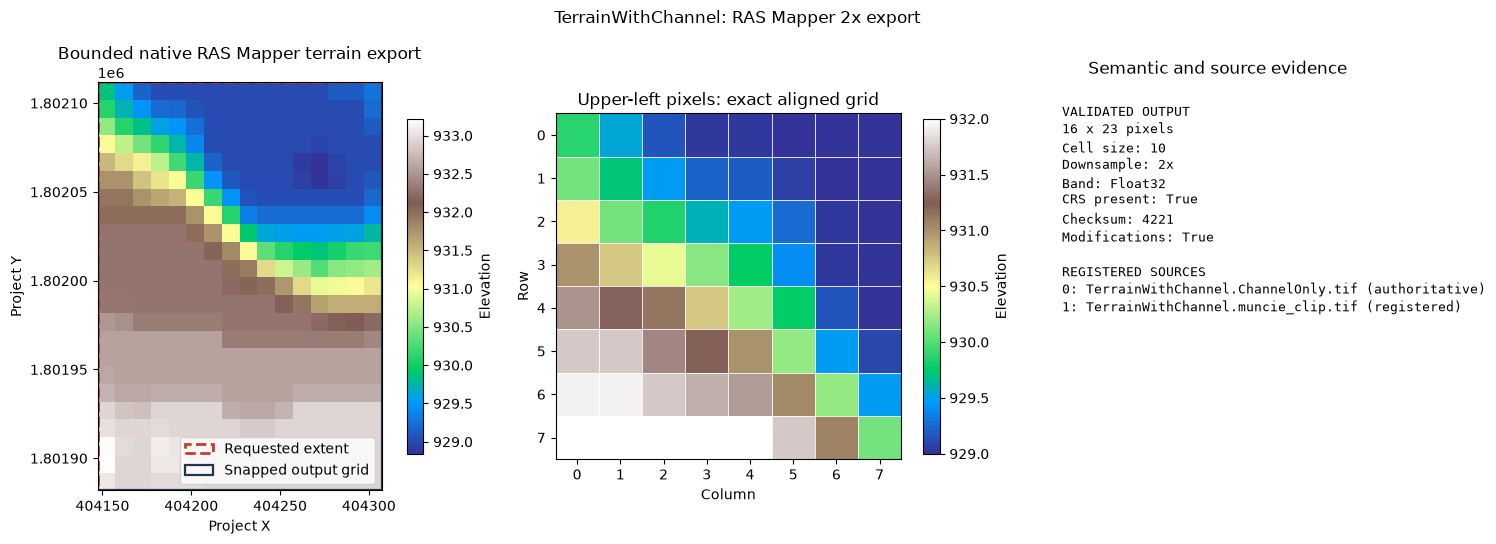

Review figure: run\review\muncie_terrain_export_evidence.png


In [8]:
if result is not None:
    import matplotlib.pyplot as plt
    import rasterio
    from matplotlib.patches import Rectangle

    with rasterio.open(result.output_path) as dataset:
        terrain = dataset.read(1, masked=True)
        bounds = dataset.bounds

    raster_extent = (bounds.left, bounds.right, bounds.bottom, bounds.top)
    fig, (ax_map, ax_grid, ax_evidence) = plt.subplots(
        1,
        3,
        figsize=(16, 5.5),
        gridspec_kw={"width_ratios": [1.15, 1.0, 0.72]},
    )

    image = ax_map.imshow(
        terrain,
        extent=raster_extent,
        origin="upper",
        cmap="terrain",
    )
    requested = result.requested_extent
    snapped = result.snapped_extent
    ax_map.add_patch(
        Rectangle(
            (requested[0], requested[1]),
            requested[2] - requested[0],
            requested[3] - requested[1],
            fill=False,
            edgecolor="#c43c2f",
            linewidth=2.0,
            linestyle="--",
            label="Requested extent",
        )
    )
    ax_map.add_patch(
        Rectangle(
            (snapped[0], snapped[1]),
            snapped[2] - snapped[0],
            snapped[3] - snapped[1],
            fill=False,
            edgecolor="#1f3552",
            linewidth=1.6,
            label="Snapped output grid",
        )
    )
    ax_map.set_title("Bounded native RAS Mapper terrain export")
    ax_map.set_xlabel("Project X")
    ax_map.set_ylabel("Project Y")
    ax_map.legend(loc="lower right")
    fig.colorbar(image, ax=ax_map, shrink=0.82, label="Elevation")

    zoom_rows = min(8, terrain.shape[0])
    zoom_columns = min(8, terrain.shape[1])
    grid_image = ax_grid.imshow(
        terrain[:zoom_rows, :zoom_columns],
        origin="upper",
        cmap="terrain",
    )
    ax_grid.set_xticks([value - 0.5 for value in range(zoom_columns + 1)], minor=True)
    ax_grid.set_yticks([value - 0.5 for value in range(zoom_rows + 1)], minor=True)
    ax_grid.grid(which="minor", color="white", linewidth=0.7, alpha=0.85)
    ax_grid.tick_params(which="minor", bottom=False, left=False)
    ax_grid.set_title("Upper-left pixels: exact aligned grid")
    ax_grid.set_xlabel("Column")
    ax_grid.set_ylabel("Row")
    fig.colorbar(grid_image, ax=ax_grid, shrink=0.82, label="Elevation")

    source_lines = []
    for _, source in result.source_inventory.sort_values("index").iterrows():
        marker = "authoritative" if bool(source["authoritative_grid"]) else "registered"
        source_lines.append(f"{int(source['index'])}: {Path(source['filename']).name} ({marker})")
    evidence_text = (
        "VALIDATED OUTPUT\n"
        f"{result.validation['columns']} x {result.validation['rows']} pixels\n"
        f"Cell size: {result.output_cell_size:g}\n"
        f"Downsample: {result.downsample_factor}x\n"
        f"Band: {result.validation['data_type']}\n"
        f"CRS present: {result.validation['crs_present']}\n"
        f"Checksum: {result.validation['checksum']}\n"
        f"Modifications: {result.rasterize_modifications}\n\n"
        "REGISTERED SOURCES\n"
        + "\n".join(source_lines)
    )
    ax_evidence.set_title("Semantic and source evidence")
    ax_evidence.axis("off")
    ax_evidence.text(
        0.0,
        0.95,
        evidence_text,
        transform=ax_evidence.transAxes,
        va="top",
        fontsize=9.5,
        family="monospace",
        linespacing=1.35,
    )

    fig.suptitle(f"{result.terrain_name}: RAS Mapper {result.downsample_factor}x export")
    fig.tight_layout()
    REVIEW_FIGURE.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(REVIEW_FIGURE, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Review figure: {run_path(REVIEW_FIGURE)}")
else:
    print("Run the native export cell to generate raster and grid visual evidence.")

## Verify the source project was not mutated

The derivative is an external product, not a newly registered terrain. Re-inventorying the `.rasmap` should therefore return the same terrain names and HDF paths, and the output TIFF must not appear among registered paths.

In [9]:
if result is not None:
    terrain_layers_after = RasMap.list_terrain_layers(
        project_path,
        ras_object=ras,
    )
    registered_after = terrain_layers_after[["name", "resolved_path"]].copy()
    pd.testing.assert_frame_equal(
        registered_before.reset_index(drop=True),
        registered_after.reset_index(drop=True),
    )
    registered_paths = {
        str(Path(path).resolve())
        for path in terrain_layers_after["resolved_path"].dropna()
    }
    assert str(result.output_path.resolve()) not in registered_paths
    print("Verified: registered terrain inventory is unchanged.")
    print(f"Derivative remains external: {run_path(result.output_path)}")
else:
    print("No export was run; the source project remains unchanged.")

Verified: registered terrain inventory is unchanged.
Derivative remains external: run\exports\muncie_terrain_with_channel_2x.tif


## Review checklist

A reviewable run should show all of the following:

- one exact registered terrain selected from the DataFrame inventory;
- a truthy `TerrainExportResult` and successful JSON receipt;
- two intersecting Muncie sources with exactly one authoritative grid;
- an exact 2x output cell size and outward-snapped bounded extent;
- one Float32 GeoTIFF band, a present CRS, finite elevations and NoData metadata, and no unexpected sidecars;
- requested and snapped bounds visible on the terrain figure, plus a pixel-grid detail panel; and
- unchanged registered terrain inventory after export.

For modification-specific semantic evidence, compare modification-off and modification-on bounded exports across a known feature and confirm that affected cells change while control cells remain stable. That focused proof belongs in the terrain-modification example rather than being inferred from Muncie's stitched sources.